<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/TEXT_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Contexto de Negócio**

Uma plataforma brasileira de agregação de notícias precisa categorizar automaticamente artigos da Folha de São Paulo, eliminando a curadoria editorial manual que hoje consome cerca de 40 horas/semana.

Você é o cientista de dados responsável por construir, comparar e recomendar a melhor abordagem para produção. O sistema precisa atingir F1 macro ≥ 0.75 para ser considerado viável operacionalmente.

Dataset:
Fonte: kaggle.com/datasets/marlesson/news-of-the-site-folhauol
Arquivo: articles.csv ·

Colunas: id, url, title, text, category

Volume: ~167.000 artigos em 48 categorias

**IMPORTAR BIBLIOTECAS**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re # expressões regulares
from collections import Counter # contar frequência de elementos
print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


**BASE: News of the Brazilian Newspaper**

In [25]:
!pip install gdown # ponte entre Google Drive e Python

In [26]:
import gdown

url = "https://drive.google.com/uc?id=1I3qWPUI9au_BEtMM9-HVjZY-_wn_tl7N"

gdown.download(url, 'articles.csv', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1I3qWPUI9au_BEtMM9-HVjZY-_wn_tl7N
From (redirected): https://drive.google.com/uc?id=1I3qWPUI9au_BEtMM9-HVjZY-_wn_tl7N&confirm=t&uuid=1f0f0021-1842-4e5b-b2ee-cf59867cf0a0
To: /content/articles.csv
100%|██████████| 504M/504M [00:12<00:00, 38.8MB/s]


'articles.csv'

**1) Exploração e curadoria do dataset**

In [27]:
df = pd.read_csv('articles.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (167053, 6)


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


**Q1 — Distribuição de classes**

Visualize a frequência de artigos por categoria (todas as 48). Qual o grau de desbalanceamento? Calcule a razão entre a categoria mais frequente e a menos frequente. Que impacto direto esse desbalanceamento tem na escolha da métrica de avaliação e na estratégia de treino?

Total de categorias: 48
Maior classe: 22022
Menor classe: 1
Razão de desbalanceamento: 22022.00


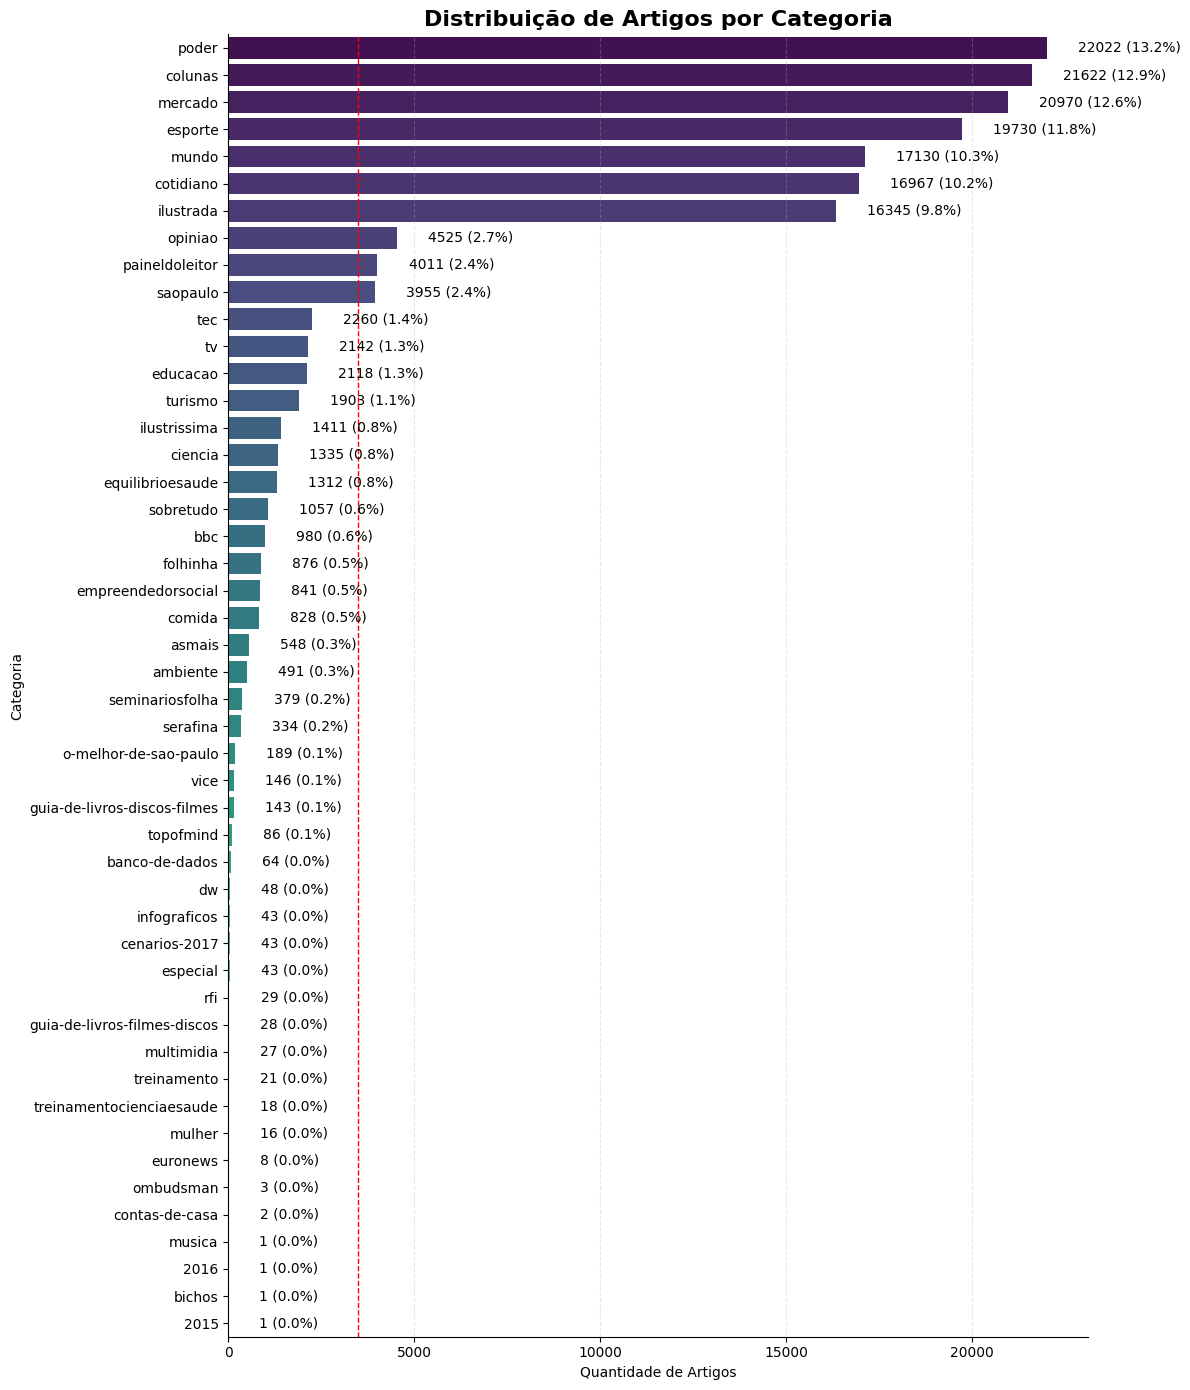

In [28]:
# Contagem por categoria (ordenado)
class_counts = df['category'].value_counts()

# Métricas de desbalanceamento
maior = class_counts.max()
menor = class_counts.min()
ratio = maior / menor

print(f'Total de categorias: {df["category"].nunique()}')
print(f'Maior classe: {maior}')
print(f'Menor classe: {menor}')
print(f'Razão de desbalanceamento: {ratio:.2f}')

# Total para porcentagem
total = class_counts.sum()

# VISUALIZAÇÃO
plt.figure(figsize=(12,14))

ax = sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)

# Linha da média
media = class_counts.mean()
plt.axvline(media, color='red', linestyle='--', linewidth=1)

# Rótulos com quantidade + porcentagem
for i, v in enumerate(class_counts.values):
    porcentagem = (v / total) * 100
    ax.text(
        v + (total * 0.005),
        i,
        f'{v} ({porcentagem:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Distribuição de Artigos por Categoria', fontsize=16, weight='bold')
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categoria')

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

*Antes de modelar, é necessário tratar o desbalanceamento extremo, pois ele pode impedir o modelo de atingir o F1 macro ≥ 0.75 exigido pelo negócio.*

Distribuição de classes e desbalanceamento

A análise da frequência de artigos por categoria mostra que o dataset possui 48 categorias com uma distribuição altamente desigual.

Maior classe: 22.022 artigos

Menor classe: 1 artigo

Razão de desbalanceamento: 22.022

Isso caracteriza um desbalanceamento extremo.

O dataset apresenta desbalanceamento extremo, com razão superior a 20.000 entre a maior e a menor classe. Esse cenário inviabiliza o uso de métricas como accuracy e exige o uso de F1 macro, que considera igualmente todas as categorias.

Além disso, torna-se necessário aplicar estratégias de tratamento de dados e ajuste de modelo para evitar viés em classes majoritárias e garantir desempenho consistente em todas as categorias.

**Q2 — Anatomia dos textos**

Compare a distribuição do comprimento (em palavras) de title e text por categoria, usando boxplots ou violinplots. Alguma categoria tem textos sistematicamente mais curtos ou mais longos? Como isso influencia sua decisão sobre qual campo usar como input?

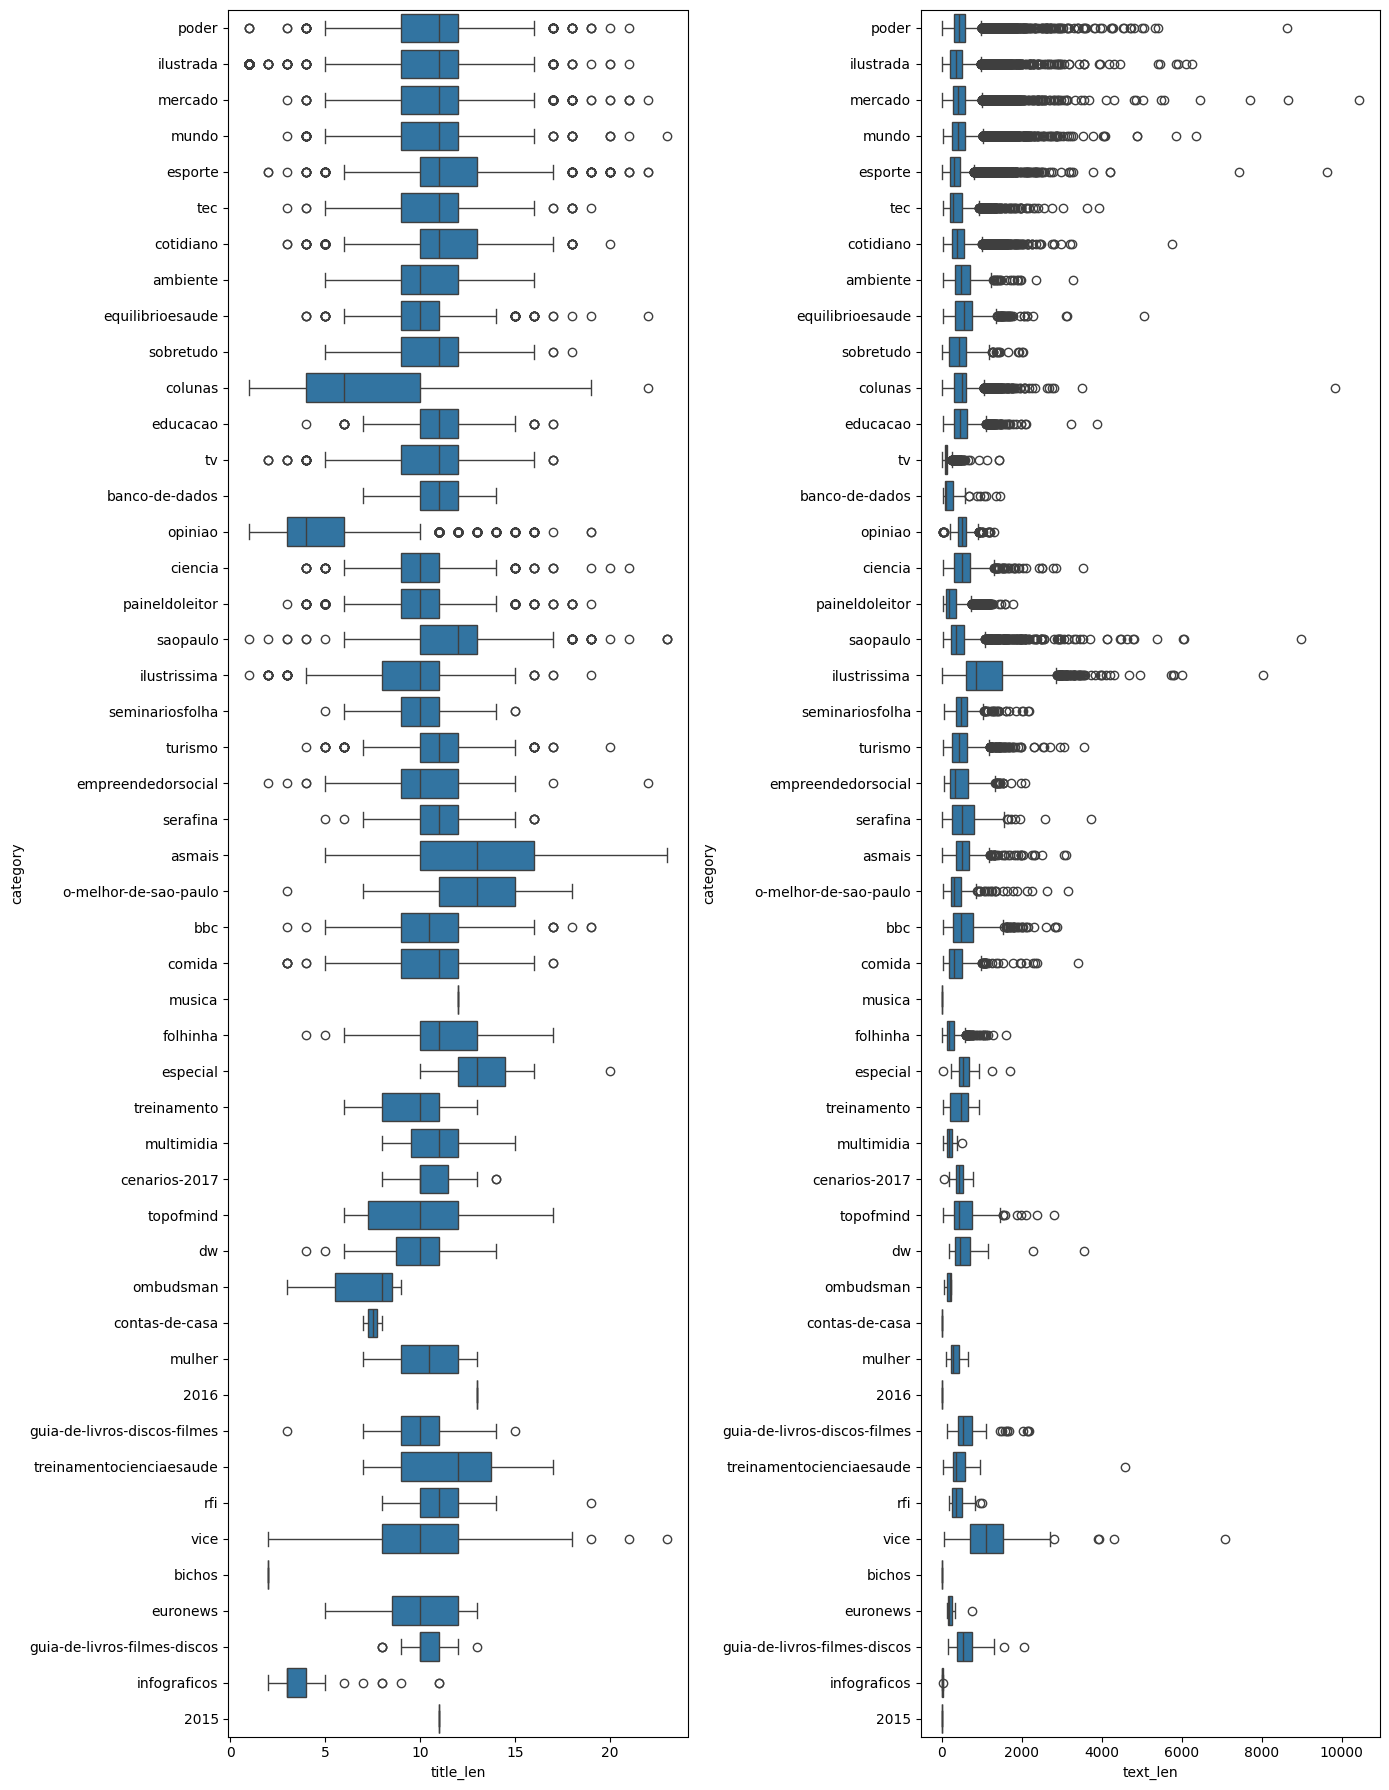

In [31]:
# CRIAR COLUNAS
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(14,18))

# TITLE
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    y='category',
    x='title_len'
)

# TEXT
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    y='category',
    x='text_len'
)

plt.tight_layout()
plt.show()

A análise dos boxplots evidencia diferenças importantes entre os campos title e text.

Os títulos apresentam menor variabilidade entre categorias, com distribuições mais concentradas e medianas próximas, geralmente entre 8 e 12 palavras. Isso indica que o título, independentemente da categoria, segue um padrão editorial relativamente uniforme, oferecendo pouca variação informacional.

Por outro lado, os textos apresentam alta dispersão e grande variação entre categorias, com presença significativa de outliers e diferenças claras de escala. Algumas categorias, como ilustríssima, colunas e saopaulo, tendem a apresentar textos mais longos, enquanto outras, como tv, infográficos e ombudsman, possuem textos sistematicamente mais curtos.

Essa heterogeneidade indica que o campo text carrega muito mais informação semântica relevante para a tarefa de classificação, permitindo capturar melhor o contexto e as particularidades de cada categoria.

Dessa forma, a escolha do input deve priorizar:

*   o uso do campo text como principal fonte de informação, devido à sua maior riqueza e variabilidade;
*   o uso complementar de title, que pode agregar sinal adicional, especialmente em casos onde o título resume bem o conteúdo.


Essa escolha é fundamental para atingir o objetivo de F1 macro ≥ 0.75, já que o uso exclusivo de títulos provavelmente limitaria a capacidade do modelo de diferenciar categorias com conteúdo semanticamente próximo.

**Q3 — Sobreposição vocabular entre categorias limítrofes**

Identifique dois pares de categorias semanticamente próximas (ex: poder e mundo; mercado e cotidiano). Para cada par, liste os 20 tokens mais frequentes em cada categoria e calcule a proporção de tokens compartilhados. O que essa sobreposição antecipa sobre a dificuldade do problema?

In [32]:
# Função simples de limpeza
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Função para extrair top tokens de uma categoria
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()
    tokens = []

    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# Função para calcular sobreposição
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    intersec = tokens1.intersection(tokens2)
    proporcao = len(intersec) / 20

    return tokens1, tokens2, intersec, proporcao

# Escolher pares semanticamente próximos
pares = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pares:
    t1, t2, inter, prop = overlap(c1, c2)

    print(f'\nCategorias: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Tokens compartilhados: {list(inter)}')
    print(f'Sobreposição: {prop:.2f}')


Categorias: poder vs mundo
Tokens poder: {'na', 'não', 'do', 'e', 'é', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'se', 'para', 'que', 'de', 'a', 'da', 'ao', 'por'}
Tokens mundo: {'na', 'não', 'as', 'e', 'do', 'é', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'se', 'para', 'que', 'de', 'a', 'da', 'por'}
Tokens compartilhados: ['na', 'não', 'do', 'e', 'é', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'se', 'para', 'que', 'de', 'a', 'da', 'por']
Sobreposição: 0.95

Categorias: mercado vs cotidiano
Tokens mercado: {'na', 'não', 'as', 'e', 'do', 'é', 'dos', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'para', 'que', 'de', 'a', 'da', 'por'}
Tokens cotidiano: {'na', 'não', 'as', 'e', 'do', 'é', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'para', 'que', 'de', 'a', 'da', 'foi', 'por'}
Tokens compartilhados: ['na', 'não', 'as', 'do', 'e', 'é', 'os', 'o', 'um', 'com', 'uma', 'no', 'em', 'para', 'que', 'de', 'a', 'da', 'por']
Sobreposição: 0.95


Os resultados estão inflados porque incluem stopwords como “de”, “a”, “o”, “que”.

👉 Isso não mede semântica, só mede estrutura da língua.

O correto é considerar tokens informativos (sem stopwords).

In [40]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese')) | {
        'pra','pro','ta','ja','né','ai','ah','vc','vcs','tbm','tb','kk','kkk'}

# PRE-PROCESSAMENTO
def preprocess(text):
    text = str(text).lower()                          # deixa tudo minusculo
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove urls
    text = re.sub(r'\S+@\S+', '', text)               # remove emails
    text = re.sub(r'\d+', '', text)                   # remove números
    text = re.sub(r'[^\w\s]', '', text)               # remove pontuação
    text = re.sub(r'\s+', ' ', text).strip()          # remove espaços extras

    tokens = text.split()

    # remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return tokens

# FUNÇÃO PARA TOP TOKENS
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()

    tokens = []
    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# FUNÇÃO DE SOBREPOSIÇÃO
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    intersec = tokens1.intersection(tokens2)
    proporcao = len(intersec) / 20

    return tokens1, tokens2, intersec, proporcao

# ANÁLISE DOS PARES
pares = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pares:
    t1, t2, inter, prop = overlap(c1, c2)

    print(f'\nCategorias: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Tokens compartilhados: {list(inter)}')
    print(f'Sobreposição: {prop:.2f}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Categorias: poder vs mundo
Tokens poder: {'contra', 'temer', 'governo', 'segundo', 'dilma', 'disse', 'lava', 'paulo', 'presidente', 'sobre', 'federal', 'câmara', 'lula', 'afirmou', 'nesta', 'ter', 'ainda', 'jato', 'cunha', 'ministro'}
Tokens mundo: {'contra', 'governo', 'trump', 'segundo', 'dois', 'após', 'disse', 'presidente', 'sobre', 'pessoas', 'anos', 'afirmou', 'estado', 'eua', 'nesta', 'ter', 'país', 'ainda', 'desde', 'países'}
Tokens compartilhados: ['contra', 'afirmou', 'governo', 'presidente', 'nesta', 'segundo', 'ter', 'sobre', 'disse', 'ainda']
Sobreposição: 0.50

Categorias: mercado vs cotidiano
Tokens mercado: {'mercado', 'governo', 'segundo', 'banco', 'disse', 'milhões', 'brasil', 'empresa', 'presidente', 'sobre', 'anos', 'empresas', 'ano', 'pode', 'nesta', 'país', 'ainda', 'diz', 'maior', 'bilhões'}
Tokens cotidiano: {'segundo', 'dois', 'cidade', 'após', 'disse', 'paulo', 'sobre', 'anos', 'pessoas', 'polícia', 'região', 'prefeitura', 'ano', 'rio', 'estado', 'nesta', 'te

Foram analisados dois pares de categorias semanticamente próximas: poder vs mundo e mercado vs cotidiano, considerando os 20 tokens mais frequentes em cada uma após remoção de stopwords.

No par poder vs mundo, observou-se uma sobreposição de 50% dos tokens, com compartilhamento de termos como “governo”, “presidente”, “disse” e “segundo”, indicando forte interseção temática, especialmente em conteúdos políticos e institucionais. Já no par mercado vs cotidiano, a sobreposição foi de 40%, sugerindo maior distinção semântica, embora ainda haja termos genéricos compartilhados.

Além disso, cada categoria apresenta tokens específicos que contribuem para sua diferenciação, como:

*   poder: “lula”, “dilma” e “cunha”;
*   mundo: “trump” e “eua”;
*   mercado: “empresa”;
*   cotidiano: “polícia” e “cidade”.

Essa sobreposição vocabular indica que existem fronteiras semânticas parcialmente difusas entre categorias próximas, o que aumenta a complexidade do problema de classificação. Como consequência, modelos baseados apenas em frequência de palavras podem ter dificuldade em distinguir essas classes, sendo necessário utilizar abordagens que capturem contexto e relações semânticas mais profundas, e não apenas tokens isolados.

*A entrega para os próximos exercícios deve considerar no mínimo as categorias `mercado`, `esporte`, `poder`, `mundo` e`cotidiano`, as outras podem ser excluídas. Fica eletivo ao aluno incluir mais categorias do que as listadas.*

**Q4 — Qual dados utilizar**

Você pode usar title, text ou title + text concatenados. A escolha é livre, mas deve ser justificada empiricamente.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# FILTRAR CATEGORIAS EXIGIDAS
categorias = ['mercado', 'esporte', 'poder', 'mundo', 'cotidiano', 'colunas']
df_filtrado = df[df['category'].isin(categorias)].copy()

# CRIAR INPUTS
df_filtrado['title_text'] = (
    df_filtrado['title'].fillna('') + ' ' +
    df_filtrado['text'].fillna('')
)

X_title = df_filtrado['title'].fillna('').astype(str)
X_text = df_filtrado['text'].fillna('').astype(str)
X_comb = df_filtrado['title_text'].fillna('').astype(str)
y = df_filtrado['category']

# SPLIT ÚNICO
train_idx, test_idx = train_test_split(
    df_filtrado.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# FUNÇÃO DE AVALIAÇÃO
def avaliar_modelo(X):
    vectorizer = TfidfVectorizer(max_features=20000)

    X_train = vectorizer.fit_transform(X.loc[train_idx])
    X_test = vectorizer.transform(X.loc[test_idx])

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # relatório (vai aparecer um para cada modelo)
    print(classification_report(y_test, y_pred))

    return f1_score(y_test, y_pred, average='macro')

# RESULTADOS
f1_title = avaliar_modelo(X_title)
f1_text = avaliar_modelo(X_text)
f1_comb = avaliar_modelo(X_comb)

print(f'F1 (title): {f1_title:.4f}')
print(f'F1 (text): {f1_text:.4f}')
print(f'F1 (title + text): {f1_comb:.4f}')

              precision    recall  f1-score   support

     colunas       0.73      0.71      0.72      4325
   cotidiano       0.82      0.84      0.83      3393
     esporte       0.93      0.92      0.93      3946
     mercado       0.79      0.81      0.80      4194
       mundo       0.87      0.86      0.87      3426
       poder       0.82      0.84      0.83      4405

    accuracy                           0.83     23689
   macro avg       0.83      0.83      0.83     23689
weighted avg       0.83      0.83      0.83     23689

              precision    recall  f1-score   support

     colunas       0.90      0.86      0.88      4325
   cotidiano       0.90      0.93      0.92      3393
     esporte       0.97      0.97      0.97      3946
     mercado       0.89      0.90      0.90      4194
       mundo       0.93      0.93      0.93      3426
       poder       0.90      0.90      0.90      4405

    accuracy                           0.92     23689
   macro avg       0.92

Os resultados mostram que o uso exclusivo de title apresenta desempenho inferior (F1 = 0.8288), o que é consistente com sua baixa densidade informacional e menor variabilidade. A inclusão da categoria colunas, caracterizada por textos mais subjetivos, contribui para a redução do desempenho, especialmente nesse cenário.

O uso do campo text melhora significativamente o desempenho (F1 = 0.9166), devido à maior riqueza semântica e contextual. Nesse caso, categorias como esporte apresentam alto desempenho (F1 ≈ 0.97), enquanto colunas permanece como a mais desafiadora.

A combinação title + text apresentou o melhor resultado (F1 = 0.9201), porém com ganho marginal em relação ao uso apenas de text, indicando que o título atua como um reforço informacional, mas não é essencial.